# HW10-11: Компьютерное зрение в PyTorch

Цель данного ноутбука:
- Выполнить классификацию на `STL10` (CNN базовый, с аугментациями, Transfer Learning ResNet18 head-only и fine-tune).
- Выполнить базовую сегментацию на `OxfordIIITPet` с помощью `DeepLabV3_ResNet50`.


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
from pathlib import Path
from PIL import Image

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Path("artifacts/figures").mkdir(parents=True, exist_ok=True)
Path("data").mkdir(parents=True, exist_ok=True)


Using device: cpu


## Часть A. Архитектура и данные `STL10`


In [12]:
# 1. Загрузка данных

class MapTransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y

base_train_dataset_raw = datasets.STL10('./data', split='train', download=True)
test_dataset_raw = datasets.STL10('./data', split='test', download=True)

train_size = 4000
val_size = len(base_train_dataset_raw) - train_size
train_subset, val_subset = random_split(base_train_dataset_raw, [train_size, val_size])

print(f"Train subset size: {len(train_subset)}, Val subset size: {len(val_subset)}, Test size: {len(test_dataset_raw)}")

# 2. Трансформы
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


Train subset size: 4000, Val subset size: 1000, Test size: 8000


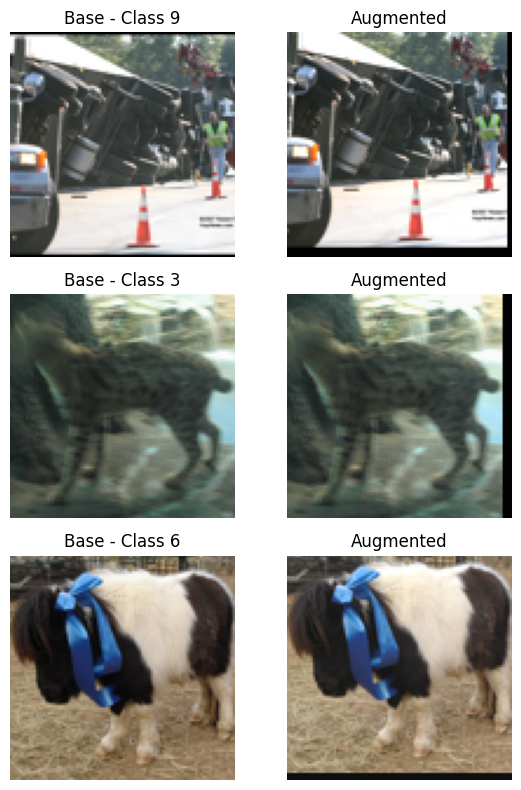

In [13]:
# Визуализация аугментаций и sanity-check
sample_idx = [random.randint(0, len(train_subset)-1) for _ in range(3)]
fig, axes = plt.subplots(3, 2, figsize=(6, 8))

for i, idx in enumerate(sample_idx):
    img_pil, label = train_subset[idx]
    
    img_base = base_transform(img_pil)
    img_base_show = img_base.permute(1, 2, 0).numpy() * 0.5 + 0.5 # unnormalize
    axes[i, 0].imshow(np.clip(img_base_show, 0, 1))
    axes[i, 0].set_title(f"Base - Class {label}")
    axes[i, 0].axis('off')
    
    img_aug = aug_transform(img_pil)
    img_aug_show = img_aug.permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[i, 1].imshow(np.clip(img_aug_show, 0, 1))
    axes[i, 1].set_title(f"Augmented")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png')
plt.show()


### Определение цикла обучения и логирования


In [14]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            running_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs, device, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None
    
    for ep in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = model.state_dict()
            
        print(f"Epoch {ep+1}/{epochs} | Train Loss: {train_loss:.3f} Acc: {train_acc:.3f} | Val Loss: {val_loss:.3f} Acc: {val_acc:.3f}")
        
    model.load_state_dict(best_weights)
    return model, history, best_val_acc


### C1 и C2: Простая CNN (С аугментациями и без)


In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

BATCH_SIZE = 64
EPOCHS_CNN = 4

# C1: Без аугментаций
print("--- C1: Simple CNN (Base) ---")
train_base_ds = MapTransformDataset(train_subset, base_transform)
val_base_ds   = MapTransformDataset(val_subset,   base_transform)
loader_train_base = DataLoader(train_base_ds, batch_size=BATCH_SIZE, shuffle=True)
loader_val_base   = DataLoader(val_base_ds,   batch_size=BATCH_SIZE, shuffle=False)

cnn_base = SimpleCNN().to(device)
cnn_base, hist_c1, val_acc_c1 = train_model(cnn_base, loader_train_base, loader_val_base, EPOCHS_CNN, device)

# C2: C аугментациями
print("\n--- C2: Simple CNN (Augmented) ---")
train_aug_ds = MapTransformDataset(train_subset, aug_transform)
val_aug_ds   = MapTransformDataset(val_subset,   base_transform) # на val берем base!
loader_train_aug = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True)
loader_val_aug   = DataLoader(val_aug_ds,   batch_size=BATCH_SIZE, shuffle=False)

cnn_aug = SimpleCNN().to(device)
cnn_aug, hist_c2, val_acc_c2 = train_model(cnn_aug, loader_train_aug, loader_val_aug, EPOCHS_CNN, device)


--- C1: Simple CNN (Base) ---
Epoch 1/4 | Train Loss: 1.890 Acc: 0.299 | Val Loss: 1.582 Acc: 0.403
Epoch 2/4 | Train Loss: 1.566 Acc: 0.412 | Val Loss: 1.459 Acc: 0.463
Epoch 3/4 | Train Loss: 1.393 Acc: 0.486 | Val Loss: 1.384 Acc: 0.483
Epoch 4/4 | Train Loss: 1.279 Acc: 0.521 | Val Loss: 1.312 Acc: 0.502

--- C2: Simple CNN (Augmented) ---
Epoch 1/4 | Train Loss: 1.995 Acc: 0.254 | Val Loss: 1.694 Acc: 0.323
Epoch 2/4 | Train Loss: 1.653 Acc: 0.377 | Val Loss: 1.502 Acc: 0.450
Epoch 3/4 | Train Loss: 1.509 Acc: 0.435 | Val Loss: 1.414 Acc: 0.474
Epoch 4/4 | Train Loss: 1.423 Acc: 0.474 | Val Loss: 1.325 Acc: 0.523


### C3 и C4: Transfer Learning с ResNet18


In [16]:
train_res_ds = MapTransformDataset(train_subset, resnet_transform)
val_res_ds   = MapTransformDataset(val_subset,   resnet_transform)
loader_train_res = DataLoader(train_res_ds, batch_size=BATCH_SIZE, shuffle=True)
loader_val_res   = DataLoader(val_res_ds,   batch_size=BATCH_SIZE, shuffle=False)

EPOCHS_RES = 2

# C3: ResNet18 Head-only
print("\n--- C3: ResNet18 (Head-only) ---")
resnet_head = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet_head.parameters():
    param.requires_grad = False

resnet_head.fc = nn.Linear(resnet_head.fc.in_features, 10)
resnet_head = resnet_head.to(device)
resnet_head, hist_c3, val_acc_c3 = train_model(resnet_head, loader_train_res, loader_val_res, EPOCHS_RES, device, lr=0.002)

# C4: ResNet18 Partial fine-tuning
print("\n--- C4: ResNet18 (Partial Fine-Tune) ---")
resnet_fine = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet_fine.parameters():
    param.requires_grad = False

for param in resnet_fine.layer4.parameters():
    param.requires_grad = True
resnet_fine.fc = nn.Linear(resnet_fine.fc.in_features, 10)
resnet_fine = resnet_fine.to(device)

resnet_fine, hist_c4, val_acc_c4 = train_model(resnet_fine, loader_train_res, loader_val_res, EPOCHS_RES, device, lr=0.0005)



--- C3: ResNet18 (Head-only) ---
Epoch 1/2 | Train Loss: 0.760 Acc: 0.790 | Val Loss: 0.291 Acc: 0.932
Epoch 2/2 | Train Loss: 0.246 Acc: 0.932 | Val Loss: 0.220 Acc: 0.939

--- C4: ResNet18 (Partial Fine-Tune) ---
Epoch 1/2 | Train Loss: 0.361 Acc: 0.883 | Val Loss: 0.319 Acc: 0.908
Epoch 2/2 | Train Loss: 0.065 Acc: 0.982 | Val Loss: 0.221 Acc: 0.940


### Выбор лучшей модели и финальный скор


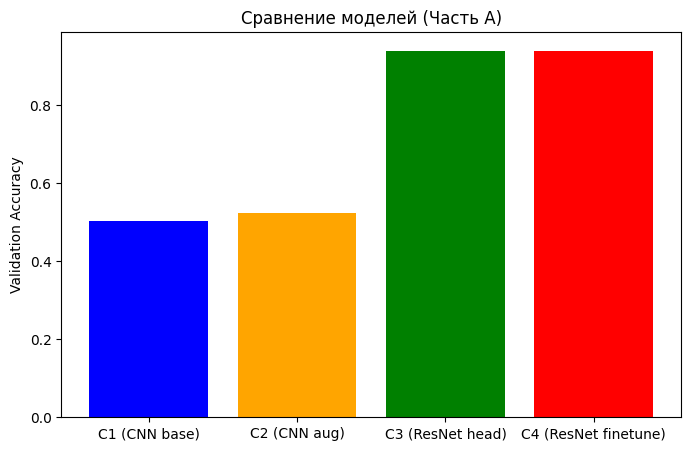

Победитель на валидации: C4 (ResNet finetune) с accuracy 0.940

--- Test Accuracy лучшей модели ---
Test Loss: 0.198, Test Acc: 0.937


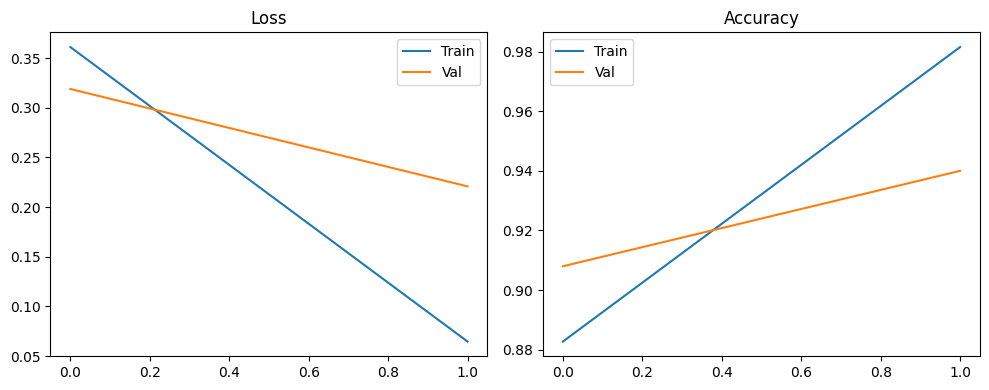

In [17]:
# Сравнение val accuracy
import json


results = {
    'C1 (CNN base)': val_acc_c1,
    'C2 (CNN aug)': val_acc_c2,
    'C3 (ResNet head)': val_acc_c3,
    'C4 (ResNet finetune)': val_acc_c4
}

plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Validation Accuracy')
plt.title('Сравнение моделей (Часть A)')
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

best_model_name = max(results, key=results.get)
print(f"Победитель на валидации: {best_model_name} с accuracy {results[best_model_name]:.3f}")

if "ResNet" in best_model_name:
    best_model = resnet_fine if results['C4 (ResNet finetune)'] > results['C3 (ResNet head)'] else resnet_head
    test_ds = MapTransformDataset(test_dataset_raw, resnet_transform)
    hist_best = hist_c4 if best_model == resnet_fine else hist_c3
else:
    best_model = cnn_aug if results['C2 (CNN aug)'] > results['C1 (CNN base)'] else cnn_base
    test_ds = MapTransformDataset(test_dataset_raw, base_transform)
    hist_best = hist_c2 if best_model == cnn_aug else hist_c1

loader_test = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = evaluate(best_model, loader_test, nn.CrossEntropyLoss(), device)
print(f"\n--- Test Accuracy лучшей модели ---")
print(f"Test Loss: {test_loss:.3f}, Test Acc: {test_acc:.3f}")

# Сохранение артефактов
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump({'best_model': best_model_name, 'seed': 42, 'batch_size': BATCH_SIZE, 'val_acc': results[best_model_name], 'test_acc': test_acc}, f)

# График обучения победителя
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_best['train_loss'], label='Train')
plt.plot(hist_best['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_best['train_acc'], label='Train')
plt.plot(hist_best['val_acc'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()


## Часть B. Сегментация на `OxfordIIITPet`
Мы загрузим датасет `OxfordIIITPet` и используем `DeepLabV3_ResNet50`. 
Предобученная на COCO модель способна находить собак (12) и котов (8). Мы объединим их вероятности, чтобы отделить " Foreground (Питомец) " от фона, что идеально соответствует задаче датасета OxfordIIITPet.


In [20]:
# 1. Загрузка данных
pet_val = datasets.OxfordIIITPet(root='./data', split='test', target_types='segmentation', download=True)

# 2. Загрузка предобученной модели
weights = models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
seg_transforms = weights.transforms()
seg_model = models.segmentation.deeplabv3_resnet50(weights=weights).to(device)
seg_model.eval()

# OxfordGT: 1 - питомец, 2 - фон, 3 - край
# DeepLabV3 (COCO+VOC): 8 - кот, 12 - собака.

def get_predictions(img_pil, threshold=0.5):
    img_t = seg_transforms(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        out = seg_model(img_t)['out']
    
    target_size = (img_pil.size[1], img_pil.size[0])
    out = torch.nn.functional.interpolate(
        out, size=target_size, mode='bilinear', align_corners=False
    )[0]
    
    probs = torch.softmax(out, dim=0)
    
    pet_prob = probs[8] + probs[12]
    
    # V1 (Базовая обработка): просто порог
    pred_v1 = (pet_prob > threshold).cpu().numpy().astype(np.uint8)
    
    # V2 (Альтернативная): порог смещен / более агрессивен для очистки артефактов
    pred_v2 = (pet_prob > 0.8).cpu().numpy().astype(np.uint8)
    
    return pred_v1, pred_v2

def calc_iou(pred_mask, gt_mask):
    # GT_mask имеет классы 1=pet, 2=bg, 3=border
    gt_bin = (gt_mask == 1).astype(np.uint8)
    intersection = np.logical_and(pred_mask, gt_bin).sum()
    union = np.logical_or(pred_mask, gt_bin).sum()
    return intersection / union if union > 0 else 0.0

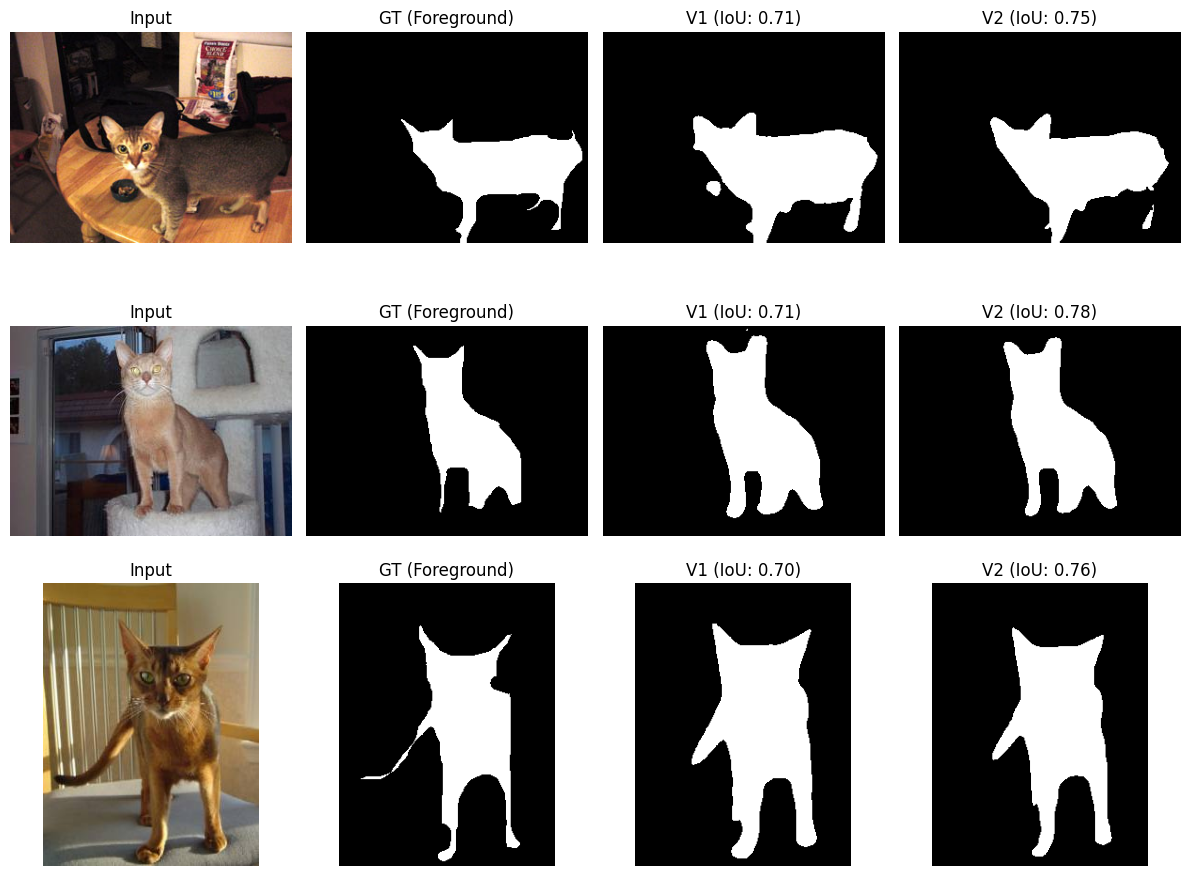

Mean IoU V1 (Base threshold=0.5): 0.7503
Mean IoU V2 (Strict threshold=0.8): 0.7798


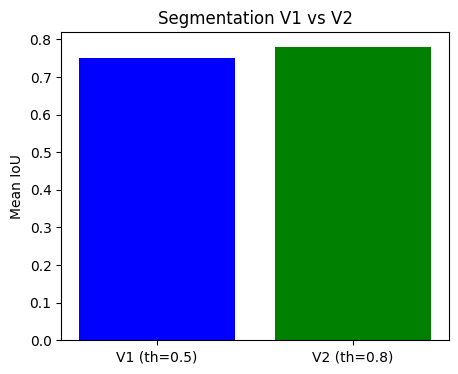

In [21]:
ious_v1, ious_v2 = [], []
num_eval = min(50, len(pet_val))

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
plot_idx = 0

for i in range(num_eval):
    img_pil, mask_pil = pet_val[i]
    gt_mask = np.array(mask_pil)
    
    v1_mask, v2_mask = get_predictions(img_pil)
    
    ious_v1.append(calc_iou(v1_mask, gt_mask))
    ious_v2.append(calc_iou(v2_mask, gt_mask))
    
    if i < 3:
        axes[plot_idx, 0].imshow(img_pil)
        axes[plot_idx, 0].set_title("Input")
        axes[plot_idx, 1].imshow(gt_mask == 1, cmap='gray')
        axes[plot_idx, 1].set_title("GT (Foreground)")
        axes[plot_idx, 2].imshow(v1_mask, cmap='gray')
        axes[plot_idx, 2].set_title(f"V1 (IoU: {ious_v1[-1]:.2f})")
        axes[plot_idx, 3].imshow(v2_mask, cmap='gray')
        axes[plot_idx, 3].set_title(f"V2 (IoU: {ious_v2[-1]:.2f})")
        
        for ax in axes[plot_idx]: ax.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_examples.png')
plt.show()

mean_iou_v1 = np.mean(ious_v1)
mean_iou_v2 = np.mean(ious_v2)

print(f"Mean IoU V1 (Base threshold=0.5): {mean_iou_v1:.4f}")
print(f"Mean IoU V2 (Strict threshold=0.8): {mean_iou_v2:.4f}")

fig_metrics, ax_m = plt.subplots(figsize=(5,4))
ax_m.bar(['V1 (th=0.5)', 'V2 (th=0.8)'], [mean_iou_v1, mean_iou_v2], color=['blue', 'green'])
ax_m.set_ylabel('Mean IoU')
ax_m.set_title('Segmentation V1 vs V2')
plt.savefig('artifacts/figures/segmentation_metrics.png')
plt.show()


## Сохранение файла `runs.csv`


In [22]:
# Формируем итоговый csv
records = [
    {'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': 'SimpleCNN Base', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': EPOCHS_CNN, 'best_val_accuracy': results['C1 (CNN base)'], 'test_accuracy': test_acc if best_model_name.startswith('C1') else None},
    {'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': 'SimpleCNN Aug', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': EPOCHS_CNN, 'best_val_accuracy': results['C2 (CNN aug)'], 'test_accuracy': test_acc if best_model_name.startswith('C2') else None},
    {'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': 'ResNet18 Head', 'optimizer': 'Adam', 'lr': 0.002, 'epochs_trained': EPOCHS_RES, 'best_val_accuracy': results['C3 (ResNet head)'], 'test_accuracy': test_acc if best_model_name.startswith('C3') else None},
    {'experiment_id': 'C4', 'task': 'classification', 'dataset': 'STL10', 'seed': 42, 'model_summary': 'ResNet18 Fine-tune', 'optimizer': 'Adam', 'lr': 0.0005, 'epochs_trained': EPOCHS_RES, 'best_val_accuracy': results['C4 (ResNet finetune)'], 'test_accuracy': test_acc if best_model_name.startswith('C4') else None},
    {'experiment_id': 'V1', 'task': 'segmentation', 'dataset': 'OxfordIIITPet', 'seed': 42, 'mean_iou': mean_iou_v1, 'notes': 'Base confidence 0.5 threshold'},
    {'experiment_id': 'V2', 'task': 'segmentation', 'dataset': 'OxfordIIITPet', 'seed': 42, 'mean_iou': mean_iou_v2, 'notes': 'Strict confidence 0.8 threshold'},
]

df_runs = pd.DataFrame(records)
df_runs.to_csv('artifacts/runs.csv', index=False)
df_runs



,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN Base,Adam,0.0010,4.0,0.502,NaN,NaN,NaN
1,C2,classification,STL10,42,SimpleCNN Aug,Adam,0.0010,4.0,0.523,NaN,NaN,NaN
2,C3,classification,STL10,42,ResNet18 Head,Adam,0.0020,2.0,0.939,NaN,NaN,NaN
3,C4,classification,STL10,42,ResNet18 Fine-tune,Adam,0.0005,2.0,0.940,0.936875,NaN,NaN
4,V1,segmentation,OxfordIIITPet,42,NaN,NaN,NaN,NaN,NaN,NaN,0.750314,Base confidence 0.5 threshold
5,V2,segmentation,OxfordIIITPet,42,NaN,NaN,NaN,NaN,NaN,NaN,0.779819,Strict confidence 0.8 threshold
